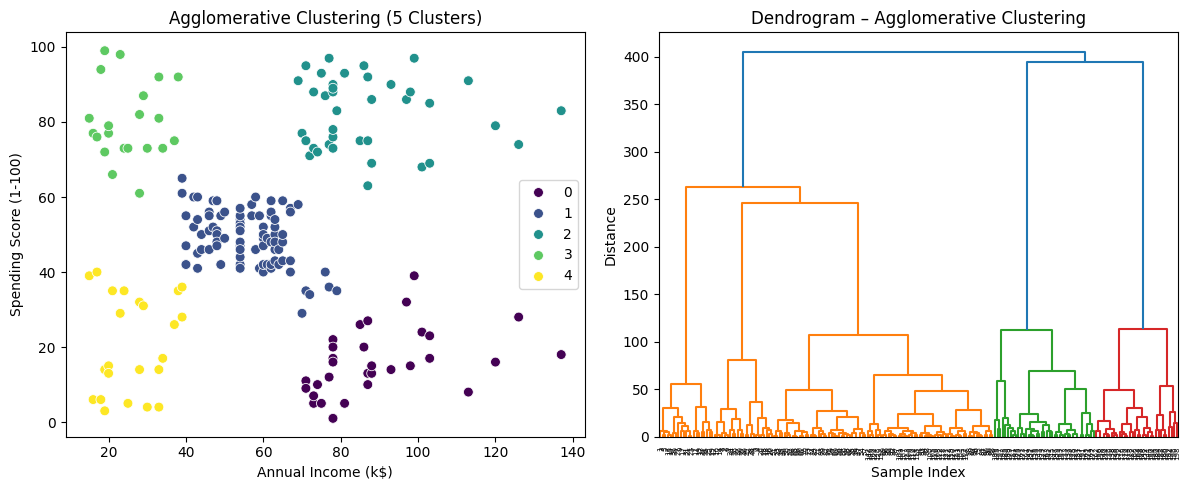

Agglomerative Cluster labels (first 10): [4 3 4 3 4 3 4 3 4 3]
Cluster distribution:
 0    32
1    85
2    39
3    21
4    23
Name: count, dtype: int64


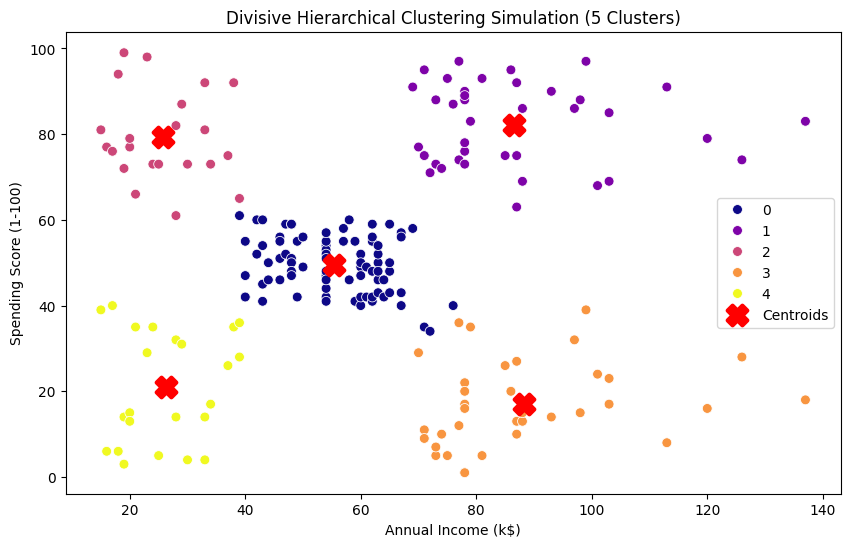

Divisive Cluster labels (first 10): [4 2 4 2 4 2 4 2 4 2]
Divisive Cluster distribution:
 0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [8]:
# Agglomerative Hierarchical Clustering (Bottom-Up) [file:155]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns

# Step 1: Load Kaggle dataset
df = pd.read_csv("Mall_Customers.csv")
X_agg = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Step 2: Apply Agglomerative Clustering (Ward linkage)
model_agg = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)
labels_agg = model_agg.fit_predict(X_agg)

# Step 3: Visualize clusters [file:155]
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(
    x=X_agg['Annual Income (k$)'],
    y=X_agg['Spending Score (1-100)'],
    hue=labels_agg,
    palette='viridis',
    s=50
)
plt.title("Agglomerative Clustering (5 Clusters)")

# Dendrogram
plt.subplot(1, 2, 2)
Z = linkage(X_agg, method='ward')
dendrogram(Z)
plt.title("Dendrogram – Agglomerative Clustering")
plt.xlabel("Sample Index")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()

print("Agglomerative Cluster labels (first 10):", labels_agg[:10])
print("Cluster distribution:\n", pd.Series(labels_agg).value_counts().sort_index())

# Divisive Hierarchical Clustering Simulation (Top-Down using KMeans)
from sklearn.cluster import KMeans

# Step 1: Same dataset
X_div = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Step 2: KMeans to simulate top-down splits
model_div = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_div = model_div.fit_predict(X_div)

# Step 3: Visualize
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_div['Annual Income (k$)'],
    y=X_div['Spending Score (1-100)'],
    hue=labels_div,
    palette='plasma',
    s=50
)
plt.scatter(model_div.cluster_centers_[:, 0], model_div.cluster_centers_[:, 1],
            color='red', marker='X', s=200, linewidths=3, label='Centroids')
plt.title("Divisive Hierarchical Clustering Simulation (5 Clusters)")
plt.legend()
plt.show()

print("Divisive Cluster labels (first 10):", labels_div[:10])
print("Divisive Cluster distribution:\n", pd.Series(labels_div).value_counts().sort_index())
